### Motor Fault Detection Model


- **Dataset:** original CSV and cleaned CSV (duplicates & outliers removed, leakage dropped)
- **Target:** `state` (multiclass: NORMAL/EMPTY_RUN/STALLED/OFF)
- **Models:** RandomForest + XGBoost (compare, select best by accuracy)
- **Export:** Best ONNX model for Node.js backend with accuracy comparison

In [19]:
# === INSTALL REQUIRED PACKAGES ===
!pip install pandas scikit-learn seaborn matplotlib xgboost skl2onnx onnxruntime joblib --quiet

In [28]:
# === IMPORTS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
)
import xgboost as xgb
import joblib
import json
import onnxruntime as ort
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
from datetime import datetime

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)
print("All libraries loaded successfully")

All libraries loaded successfully


In [21]:
# === DATASET CONFIG ===
DATASET_ORIGINAL = "../dataset/motor_dataset.csv"
DATASET_CLEAN = "../dataset/motor_dataset_clean.csv"

HEADERS = [
    "timestamp", "motor_id", "rpm", "vibration_hz", "current_amp",
    "temperature_c", "power_factor", "state", "status", "alert_code",
]

TARGET_COL = "state"  # Changed to state (multiclass)
DROP_COLS = ["status", "alert_code"]  # Remove leakage

def load_dataset(path):
    df = pd.read_csv(path, header=None, names=HEADERS)
    df = df.drop(columns=DROP_COLS, errors="ignore")
    return df

def describe_dataset(name, df):
    print(f"{name} shape: {df.shape}")
    print(f"{name} columns: {list(df.columns)}")
    if TARGET_COL not in df.columns:
        raise ValueError(f"Missing target column: {TARGET_COL}")
    print(f"{name} target distribution:")
    print(df[TARGET_COL].value_counts().sort_index())
    print("")

df_original = load_dataset(DATASET_ORIGINAL)
df_clean = load_dataset(DATASET_CLEAN)

describe_dataset("Original", df_original)
describe_dataset("Cleaned", df_clean)

Original shape: (27190, 8)
Original columns: ['timestamp', 'motor_id', 'rpm', 'vibration_hz', 'current_amp', 'temperature_c', 'power_factor', 'state']
Original target distribution:
state
EMPTY_RUN     1397
NORMAL       25432
STALLED        361
Name: count, dtype: int64

Cleaned shape: (23628, 8)
Cleaned columns: ['timestamp', 'motor_id', 'rpm', 'vibration_hz', 'current_amp', 'temperature_c', 'power_factor', 'state']
Cleaned target distribution:
state
0    23628
Name: count, dtype: int64



## 2. Exploratory Data Analysis (EDA)

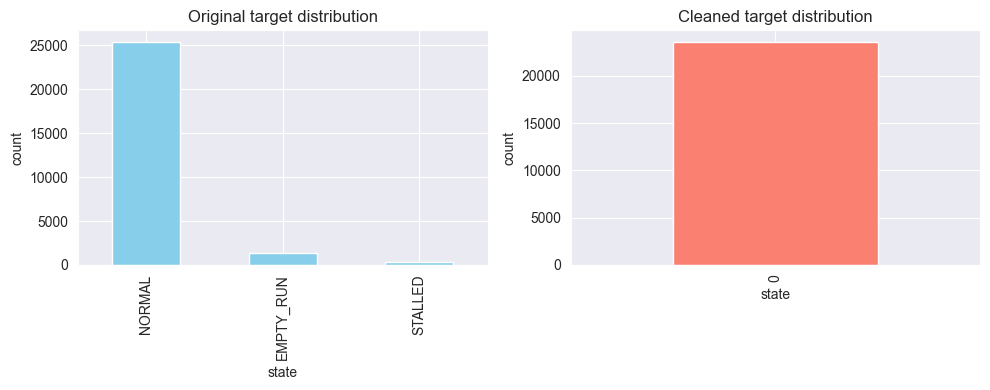

In [22]:
# Target distribution comparison
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df_original[TARGET_COL].value_counts().plot(kind="bar", color="skyblue")
plt.title("Original target distribution")
plt.xlabel(TARGET_COL)
plt.ylabel("count")

plt.subplot(1, 2, 2)
clean_counts = df_clean[TARGET_COL].value_counts()
if clean_counts.empty:
    plt.text(0.5, 0.5, "No data in cleaned set", ha="center", va="center")
    plt.axis("off")
else:
    clean_counts.plot(kind="bar", color="salmon")
    plt.title("Cleaned target distribution")
    plt.xlabel(TARGET_COL)
    plt.ylabel("count")

plt.tight_layout()
plt.show()

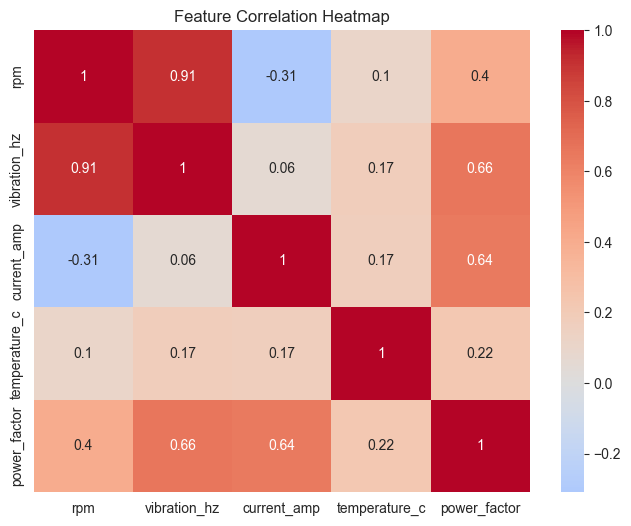

In [23]:
# Correlation heatmap (original dataset)
plt.figure(figsize=(8, 6))
numeric_cols = ["rpm", "vibration_hz", "current_amp", "temperature_c", "power_factor"]
corr = df_original[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

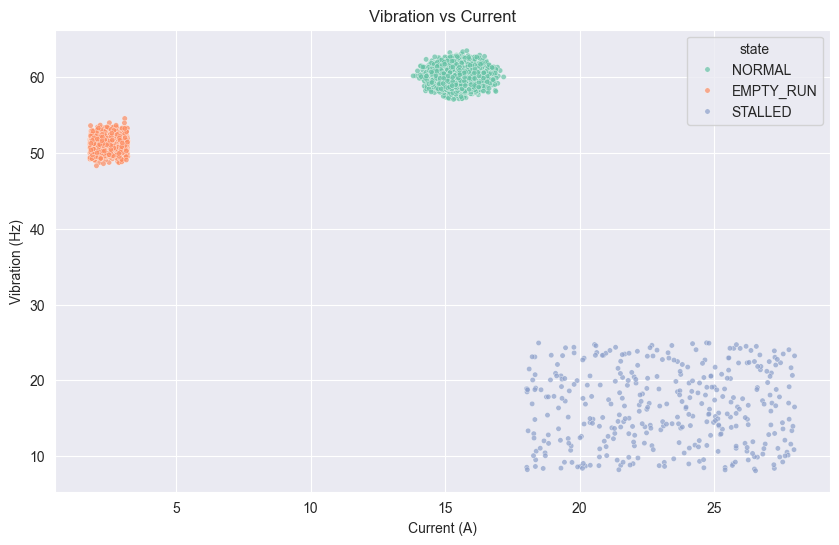

In [24]:
# Vibration vs Current (colored by target)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_original,
    x="current_amp",
    y="vibration_hz",
    hue=TARGET_COL,
    alpha=0.7,
    s=15,
    palette="Set2"
    )
plt.title("Vibration vs Current")
plt.xlabel("Current (A)")
plt.ylabel("Vibration (Hz)")
plt.legend(title=TARGET_COL)
plt.show()

C:\Users\bglah\AppData\Local\Temp\ipykernel_7780\3494442351.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_original, x=TARGET_COL, y=col, palette="Set2")
C:\Users\bglah\AppData\Local\Temp\ipykernel_7780\3494442351.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_original, x=TARGET_COL, y=col, palette="Set2")
C:\Users\bglah\AppData\Local\Temp\ipykernel_7780\3494442351.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_original, x=TARGET_COL, y=col, palette="Set2")
C:\Users\bglah\AppData\Local\Temp\ipykernel_77

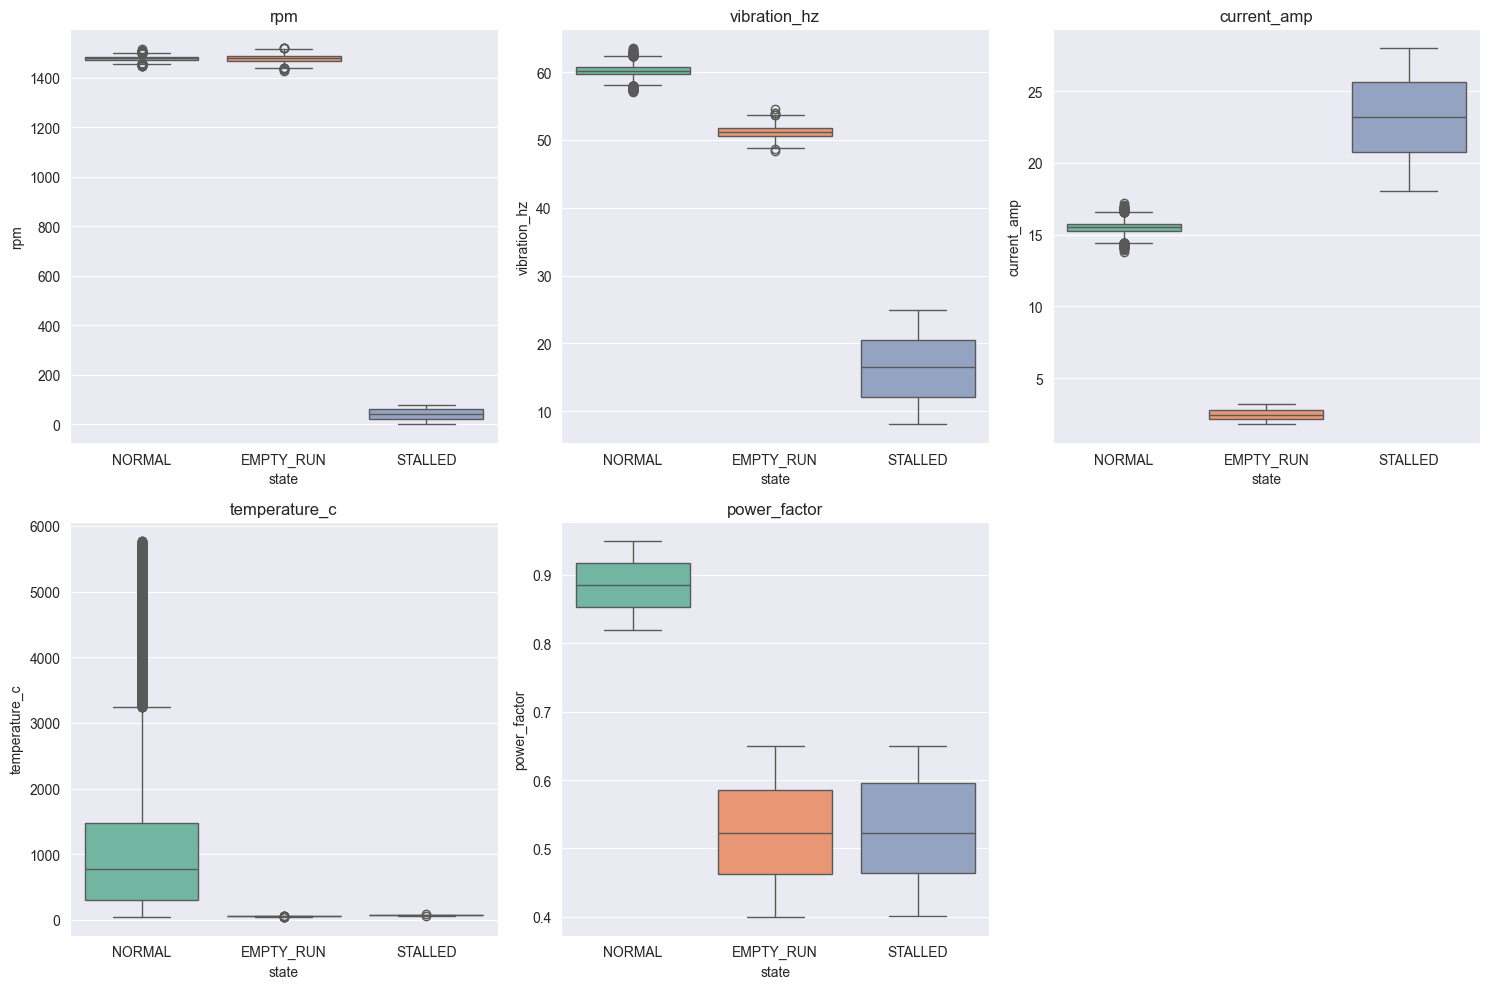

In [25]:
# Box plots - feature differences by target
features = ["rpm", "vibration_hz", "current_amp", "temperature_c", "power_factor"]
plt.figure(figsize=(15, 10))
for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df_original, x=TARGET_COL, y=col, palette="Set2")
    plt.title(col)
    plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [26]:
# === FEATURE ENGINEERING ===
def add_features(df):
    df = df.copy()
    df["vib_per_amp"] = df["vibration_hz"] / (df["current_amp"] + 0.1)
    df["current_ratio"] = df["current_amp"] / 15.5
    df["vibration_dev"] = (df["vibration_hz"] - 60.2).abs()
    df["temp_rise"] = df["temperature_c"] - 48.0
    df["power_kw"] = df["current_amp"] * 230 * df["power_factor"] / 1000
    df["high_current_low_rpm"] = ((df["current_amp"] > 22) & (df["rpm"] < 200)).astype(int)
    return df

df_original_fe = add_features(df_original)
df_clean_fe = add_features(df_clean)

print("Engineered features added.")
print("Original shape:", df_original_fe.shape)
print("Cleaned shape:", df_clean_fe.shape)

Engineered features added.
Original shape: (27190, 14)
Cleaned shape: (23628, 14)


## 4. Prepare Training Data

In [29]:
feature_cols = [
    "rpm", "vibration_hz", "current_amp", "temperature_c", "power_factor",
    "vib_per_amp", "current_ratio", "vibration_dev", "temp_rise", "power_kw", "high_current_low_rpm",
]

def train_and_evaluate(df, label, model_type="rf"):
    """Train RF or XGB and return metrics dict"""
    if df[TARGET_COL].nunique() < 2:
        print(f"{label}: Only one class present. Skipping training.")
        return None
    
    X = df[feature_cols]
    y = df[TARGET_COL]
    
    # Encode labels for XGBoost (RF handles strings fine, but XGB needs numeric)
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    X_train, X_test, y_train, y_test, y_train_orig, y_test_orig = train_test_split(
        X, y_encoded, y, test_size=0.25, random_state=42, stratify=y_encoded
    )
    
    if model_type == "rf":
        model = RandomForestClassifier(
            n_estimators=300, max_depth=18, min_samples_split=5,
            class_weight="balanced", random_state=42, n_jobs=-1
        )
        model.fit(X_train, y_train_orig)  # RF uses original string labels
        y_pred = model.predict(X_test)
        y_pred_orig = y_pred
    else:  # xgb
        model = xgb.XGBClassifier(
            n_estimators=300, max_depth=12, learning_rate=0.1,
            subsample=0.9, colsample_bytree=0.8, random_state=42,
            eval_metric="mlogloss"
        )
        model.fit(X_train, y_train)  # XGB uses encoded labels
        y_pred = model.predict(X_test)
        y_pred_orig = le.inverse_transform(y_pred)  # Decode back to strings
    
    metrics = {
        "accuracy": accuracy_score(y_test_orig, y_pred_orig),
        "f1_macro": f1_score(y_test_orig, y_pred_orig, average="macro"),
        "precision": precision_score(y_test_orig, y_pred_orig, average="macro", zero_division=0),
        "recall": recall_score(y_test_orig, y_pred_orig, average="macro", zero_division=0),
    }
    
    return {
        "label": label,
        "model_type": model_type,
        "model": model,
        "X_test": X_test,
        "y_test": y_test_orig,
        "y_pred": y_pred_orig,
        "metrics": metrics,
    }

# Train both baseline RF and baseline XGB on original
baseline_rf = train_and_evaluate(df_original_fe, "Original - RandomForest", "rf")
baseline_xgb = train_and_evaluate(df_original_fe, "Original - XGBoost", "xgb")

# Train both on cleaned
clean_rf = train_and_evaluate(df_clean_fe, "Cleaned - RandomForest", "rf")
clean_xgb = train_and_evaluate(df_clean_fe, "Cleaned - XGBoost", "xgb")

# Pick best by accuracy
candidates = [baseline_rf, baseline_xgb, clean_rf, clean_xgb]
candidates = [c for c in candidates if c is not None]

if candidates:
    best = max(candidates, key=lambda x: x["metrics"]["accuracy"])
    print("\n" + "="*70)
    print(f"BEST MODEL: {best['label']} (Accuracy: {best['metrics']['accuracy']:.4f})")
    print("="*70)
    print("Metrics:", best["metrics"])
    print("\nACCURACY COMPARISON:")
    for c in sorted(candidates, key=lambda x: x["metrics"]["accuracy"], reverse=True):
        print(f"  {c['label']}: {c['metrics']['accuracy']:.4f}")

Cleaned - RandomForest: Only one class present. Skipping training.
Cleaned - XGBoost: Only one class present. Skipping training.

BEST MODEL: Original - RandomForest (Accuracy: 1.0000)
Metrics: {'accuracy': 1.0, 'f1_macro': 1.0, 'precision': 1.0, 'recall': 1.0}

ACCURACY COMPARISON:
  Original - RandomForest: 1.0000
  Original - XGBoost: 1.0000


## 5. Train Random Forest (Best balance of speed & accuracy)

In [30]:
# Auto-select best model (already done above)
if 'best' in locals() and best is not None:
    print(f"\nUsing: {best['label']} for downstream export")
else:
    print("No valid models available")


Using: Original - RandomForest for downstream export


## 6. Evaluation & Charts

Classification Report:
              precision    recall  f1-score   support

   EMPTY_RUN     1.0000    1.0000    1.0000       349
      NORMAL     1.0000    1.0000    1.0000      6359
     STALLED     1.0000    1.0000    1.0000        90

    accuracy                         1.0000      6798
   macro avg     1.0000    1.0000    1.0000      6798
weighted avg     1.0000    1.0000    1.0000      6798



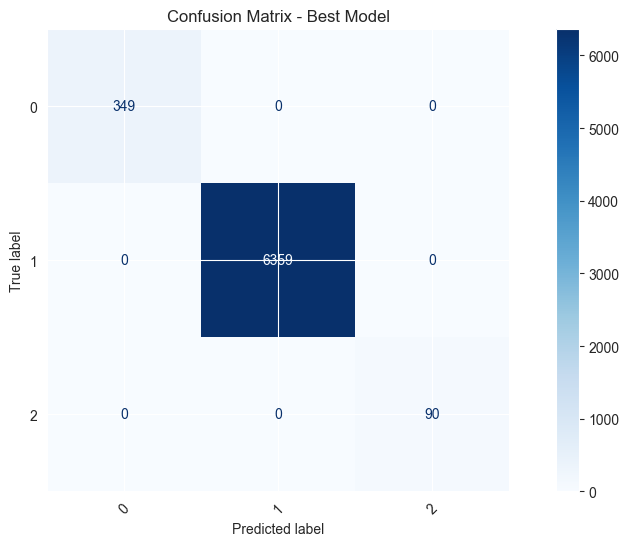

Skipping ROC/PR plots: The target y is not binary. Got multiclass type of target.


In [31]:
if best is not None:
    print("Classification Report:")
    print(classification_report(best["y_test"], best["y_pred"], digits=4))

    cm = confusion_matrix(best["y_test"], best["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Confusion Matrix - Best Model")
    plt.show()

    # ROC and PR curves for binary target
    try:
        y_proba = best["model"].predict_proba(best["X_test"])[:, 1]
        RocCurveDisplay.from_predictions(best["y_test"], y_proba)
        plt.title("ROC Curve")
        plt.show()
        PrecisionRecallDisplay.from_predictions(best["y_test"], y_proba)
        plt.title("Precision-Recall Curve")
        plt.show()
        print("ROC AUC:", roc_auc_score(best["y_test"], y_proba))
        print("Average precision:", average_precision_score(best["y_test"], y_proba))
    except Exception as exc:
        print("Skipping ROC/PR plots:", exc)
else:
    print("No model to evaluate.")

C:\Users\bglah\AppData\Local\Temp\ipykernel_7780\228996305.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")


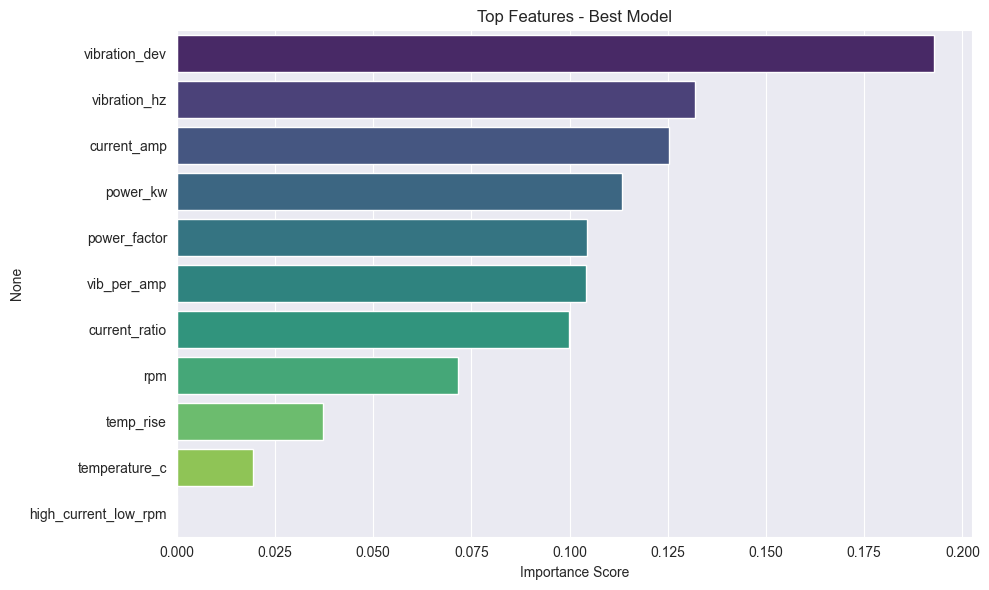

In [32]:
if best is not None:
    importances = best["model"].feature_importances_
    feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")
    plt.title("Top Features - Best Model")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()
else:
    print("No feature importances available.")

## 7. (Optional) XGBoost â€“ Usually even higher accuracy

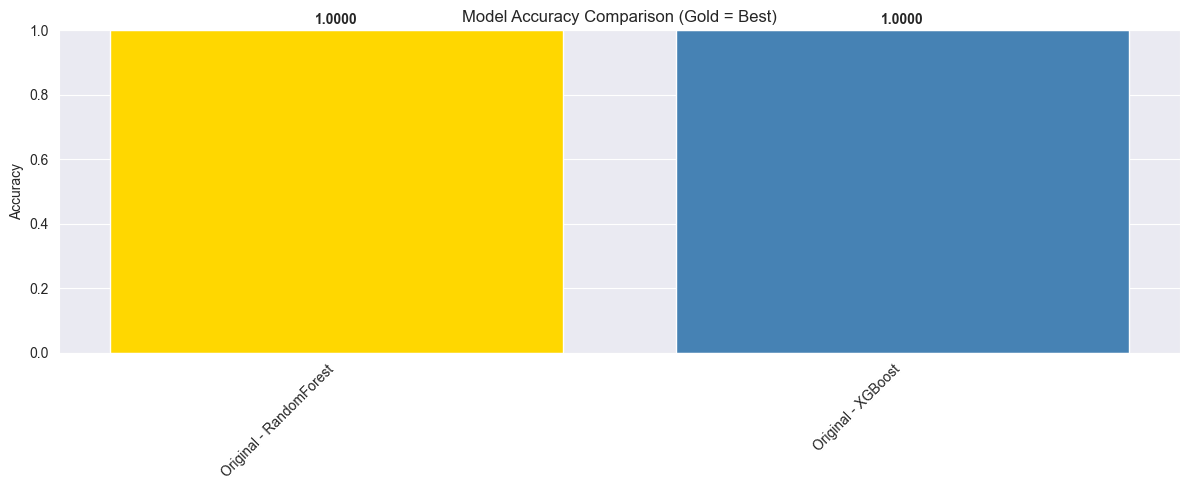

In [33]:
# Accuracy comparison visualization
if candidates:
    model_labels = [c['label'] for c in candidates]
    accuracies = [c['metrics']['accuracy'] for c in candidates]
    colors = ['gold' if c['label'] == best['label'] else 'steelblue' for c in candidates]
    
    plt.figure(figsize=(12, 5))
    bars = plt.bar(range(len(model_labels)), accuracies, color=colors)
    plt.xticks(range(len(model_labels)), model_labels, rotation=45, ha='right')
    plt.ylabel('Accuracy')
    plt.title('Model Accuracy Comparison (Gold = Best)')
    plt.ylim([0, 1])
    for i, (label, acc) in enumerate(zip(model_labels, accuracies)):
        plt.text(i, acc + 0.02, f'{acc:.4f}', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8. Save Models

In [34]:
if best is not None:
    # 1. Save as Joblib (for Python)
    joblib.dump(best["model"], "motor_fault_rf_model.pkl")
    print("Saved: motor_fault_rf_model.pkl")

    # 2. Save as ONNX (for Node.js backend)
    initial_type = [("float_input", FloatTensorType([None, len(feature_cols)]))]
    onnx_model = convert_sklearn(best["model"], initial_types=initial_type, target_opset=13)
    with open("motor_fault_model.onnx", "wb") as f:
        f.write(onnx_model.SerializeToString())
    print("Saved: motor_fault_model.onnx")

    # 3. Save feature list for Node.js
    with open("feature_columns.json", "w") as f:
        json.dump(feature_cols, f)
    print("Saved: feature_columns.json")
else:
    print("No model to save.")

Saved: motor_fault_rf_model.pkl
Saved: motor_fault_model.onnx
Saved: feature_columns.json


## 9. Test ONNX inference in notebook (same as Node.js)

In [35]:
if best is not None:
    sess = ort.InferenceSession("motor_fault_model.onnx")
    input_name = sess.get_inputs()[0].name

    sample = best["X_test"].iloc[0:1].values.astype(np.float32)
    pred_onnx = sess.run(None, {input_name: sample})[0]

    print("ONNX prediction:", pred_onnx[0])
    print("True label:", best["y_test"].iloc[0])
else:
    print("No model available for ONNX test.")

ONNX prediction: NORMAL
True label: NORMAL
